In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [26]:
states    = ['E', '5', 'I']
n_states  = len(states)
state_idx = {s: i for i, s in enumerate(states)}

obs_symbols = ['A', 'C', 'G', 'T']
obs_idx = {s: i for i, s in enumerate(obs_symbols)}

# Начальные вероятности
pi = np.array([1.0, 0.0, 0.0])

# Матрица переходов A
A = np.array([
    [0.9, 0.1, 0.0],
    [0.0, 0.0, 1.0],
    [0.0, 0.0, 0.9],
])

# Вероятность завершения цепи из каждого состояния
p_end = np.array([0.0, 0.0, 0.1])

# Матрица эмиссий B
B = np.array([
    [0.25, 0.25, 0.25, 0.25],
    [0.05, 0.00, 0.95, 0.00],
    [0.40, 0.10, 0.10, 0.40],
])

# Логарифмы параметров
NEG_INF   = -np.inf
log_pi    = np.where(pi    > 0, np.log(pi),    NEG_INF)
log_A     = np.where(A     > 0, np.log(A),     NEG_INF)
log_B     = np.where(B     > 0, np.log(B),     NEG_INF)
log_p_end = np.where(p_end > 0, np.log(p_end), NEG_INF)

/tmp/ipykernel_7928/975286101.py:30: RuntimeWarning: divide by zero encountered in log
  log_pi    = np.where(pi    > 0, np.log(pi),    NEG_INF)
/tmp/ipykernel_7928/975286101.py:31: RuntimeWarning: divide by zero encountered in log
  log_A     = np.where(A     > 0, np.log(A),     NEG_INF)
/tmp/ipykernel_7928/975286101.py:32: RuntimeWarning: divide by zero encountered in log
  log_B     = np.where(B     > 0, np.log(B),     NEG_INF)
/tmp/ipykernel_7928/975286101.py:33: RuntimeWarning: divide by zero encountered in log
  log_p_end = np.where(p_end > 0, np.log(p_end), NEG_INF)


In [16]:
# Последовательность из статьи
# CTTCATGTGAAAGCAGACGTAAGTCA — 26 символов
sequence_str = "CTTCATGTGAAAGCAGACGTAAGTCA"
observation  = [obs_idx[c] for c in sequence_str]
T_len        = len(observation)
print(f"Последовательность: {sequence_str}  (длина {T_len})\n")

Последовательность: CTTCATGTGAAAGCAGACGTAAGTCA  (длина 26)



In [17]:
def logsumexp(arr):
    """log(sum(exp(arr))), численно устойчиво."""
    arr = np.asarray(arr, dtype=float)
    mask = arr > NEG_INF
    if not np.any(mask):
        return NEG_INF
    m = arr[mask].max()
    return m + np.log(np.sum(np.exp(arr[mask] - m)))


In [27]:
# 2.1 Алгоритм Витерби
def viterbi(obs):
    T, N = len(obs), n_states
    delta = np.full((T, N), NEG_INF)
    psi   = np.zeros((T, N), dtype=int)

    # t = 0
    delta[0] = log_pi + log_B[:, obs[0]]

    for t in range(1, T):
        for j in range(N):
            scores   = delta[t-1] + log_A[:, j]
            best     = int(np.argmax(scores))
            delta[t, j] = scores[best] + log_B[j, obs[t]]
            psi[t, j]   = best

    final   = delta[T-1] + log_p_end
    last    = int(np.argmax(final))
    log_p   = final[last]

    path       = [0] * T
    path[T-1]  = last
    for t in range(T-2, -1, -1):
        path[t] = psi[t+1, path[t+1]]

    return [states[i] for i in path], log_p, delta

In [28]:
# 2.2 Алгоритм Forward
def forward(obs):
    T, N = len(obs), n_states
    alpha = np.full((T, N), NEG_INF)

    alpha[0] = log_pi + log_B[:, obs[0]]

    for t in range(1, T):
        for j in range(N):
            alpha[t, j] = logsumexp(alpha[t-1] + log_A[:, j]) + log_B[j, obs[t]]

    log_p = logsumexp(alpha[T-1] + log_p_end)
    return alpha, log_p


In [29]:
# 2.3 Алгоритм Backward
def backward(obs):
    T, N = len(obs), n_states
    beta = np.full((T, N), NEG_INF)

    beta[T-1] = log_p_end

    for t in range(T-2, -1, -1):
        for i in range(N):
            beta[t, i] = logsumexp(
                log_A[i] + log_B[:, obs[t+1]] + beta[t+1]
            )
    return beta

In [30]:
# Апостериорное декодирование (Forward-Backward, γ)
def posterior(alpha, beta, log_p):
    return np.exp(alpha + beta - log_p)


In [31]:
# Запуск на последовательности
path, lp_vit, delta = viterbi(observation)
alpha, lp_fwd       = forward(observation)
beta                = backward(observation)
gamma               = posterior(alpha, beta, lp_fwd)

# Проверка Backward
lp_bwd = logsumexp(log_pi + log_B[:, observation[0]] + beta[0])

print("2.1 Алгоритм Витерби")
print(f"Декодированный путь:  {''.join(path)}")
print(f"Log P(путь)         = {lp_vit:.6f}")
print(f"P(путь)             = {np.exp(lp_vit):.4e}")
print()
print(f"{'t':>3} {'nt':>3}  state   {'δ(E)':>12} {'δ(5)':>12} {'δ(I)':>12}")
for t, (nt, st) in enumerate(zip(sequence_str, path)):
    row = "  ".join(f"{np.exp(delta[t,i]):>12.4e}" for i in range(n_states))
    print(f"{t+1:>3}  {nt}    {st}    {row}")


print("2.2 Алгоритм Forward")
print(f"Log P(O|λ) = {lp_fwd:.6f}")
print(f"P(O|λ)     = {np.exp(lp_fwd):.6e}")
print(f"\nПроверка через Backward: {np.exp(lp_bwd):.6e}")
print(f"Совпадают: {'ДА' if abs(lp_fwd - lp_bwd) < 1e-8 else 'НЕТ'}")

print("2.3 Апостериорное декодирование")
print(f"{'t':>3} {'nt':>3}  {'γ(E)':>8} {'γ(5)':>8} {'γ(I)':>8}  argmax")
print("-" * 52)
for t in range(T_len):
    best = states[int(np.argmax(gamma[t]))]
    print(f"{t+1:>3}  {sequence_str[t]}   "
          f"{gamma[t,0]:>8.4f} {gamma[t,1]:>8.4f} {gamma[t,2]:>8.4f}  {best}")
print()
print("Проверка:")
for t in range(T_len):
    s = gamma[t].sum()
    ok = "ДА" if abs(s - 1.0) < 1e-8 else "НЕТ"
    print(f"  t={t+1:2d}: {s:.8f} {ok}")



2.1 Алгоритм Витерби
Декодированный путь:  EEEEEEEEEEEEEEEEEE5IIIIIII
Log P(путь)         = -41.219678
P(путь)             = 1.2546e-18

  t  nt  state           δ(E)         δ(5)         δ(I)
  1  C    E      2.5000e-01    0.0000e+00    0.0000e+00
  2  T    E      5.6250e-02    0.0000e+00    0.0000e+00
  3  T    E      1.2656e-02    0.0000e+00    0.0000e+00
  4  C    E      2.8477e-03    0.0000e+00    0.0000e+00
  5  A    E      6.4072e-04    1.4238e-05    0.0000e+00
  6  T    E      1.4416e-04    0.0000e+00    5.6953e-06
  7  G    E      3.2437e-05    1.3695e-05    5.1258e-07
  8  T    E      7.2982e-06    0.0000e+00    5.4782e-06
  9  G    E      1.6421e-06    6.9333e-07    4.9304e-07
 10  A    E      3.6947e-07    8.2105e-09    2.7733e-07
 11  A    E      8.3131e-08    1.8474e-09    9.9840e-08
 12  A    E      1.8705e-08    4.1566e-10    3.5942e-08
 13  G    E      4.2085e-09    1.7769e-09    3.2348e-09
 14  C    E      9.4692e-10    0.0000e+00    2.9113e-10
 15  A    E      2.1306

Text(0.5, 0, 'Позиция t  (номер + нуклеотид)')

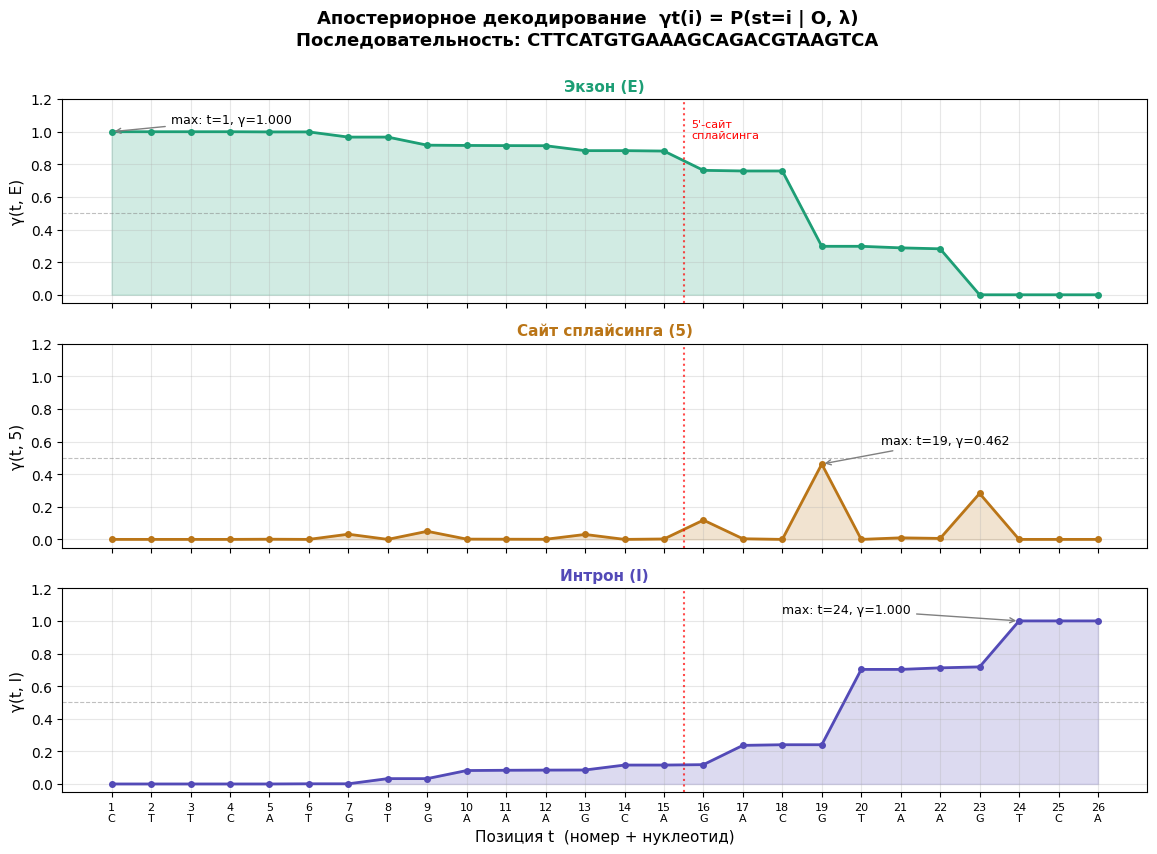

In [32]:
t_axis = np.arange(1, T_len + 1)
colors = {'E': '#1D9E75', '5': '#BA7517', 'I': '#534AB7'}
titles = {'E': 'Экзон (E)', '5': 'Сайт сплайсинга (5)', 'I': 'Интрон (I)'}
cidx   = {'E': 0, '5': 1, 'I': 2}

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle(
    "Апостериорное декодирование  γt(i) = P(st=i | O, λ)\n"
    "Последовательность: CTTCATGTGAAAGCAGACGTAAGTCA",
    fontsize=13, fontweight='bold'
)

for ax, state in zip(axes, ['E', '5', 'I']):
    y = gamma[:, cidx[state]]
    c = colors[state]
    ax.fill_between(t_axis, y, alpha=0.2, color=c)
    ax.plot(t_axis, y, color=c, lw=2, marker='o', ms=4, label=state)
    ax.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5)

    tmax = int(np.argmax(y)) + 1
    vmax = float(y.max())
    offset_x = tmax + 1.5 if tmax < T_len - 3 else tmax - 6
    offset_y = min(vmax + 0.12, 1.05)
    ax.annotate(
        f"max: t={tmax}, γ={vmax:.3f}",
        xy=(tmax, vmax), xytext=(offset_x, offset_y),
        fontsize=9, arrowprops=dict(arrowstyle='->', color='gray', lw=1)
    )
    ax.set_ylabel(f"γ(t, {state})", fontsize=11)
    ax.set_ylim(-0.05, 1.2)
    ax.set_title(titles[state], color=c, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(t_axis)
    ax.set_xticklabels([f"{i+1}\n{nt}" for i, nt in enumerate(sequence_str)], fontsize=8)

for ax in axes:
    ax.axvline(15.5, color='red', ls=':', lw=1.5, alpha=0.7)
axes[0].text(15.7, 1.08, "5'-сайт\nсплайсинга", fontsize=8, color='red', va='top')

axes[2].set_xlabel("Позиция t  (номер + нуклеотид)", fontsize=11)


In [34]:
print("Проверка O = CGT (задание 1)")
obs3 = [obs_idx[c] for c in "CGT"]

path3, lp3, _  = viterbi(obs3)
alpha3, lpf3   = forward(obs3)
beta3          = backward(obs3)
gamma3         = posterior(alpha3, beta3, lpf3)

print(f"Путь Витерби: {'→'.join(path3)}   P = {np.exp(lp3):.8f}")
print(f"P(O|λ)      = {np.exp(lpf3):.8f}")

print("A-матрица:")
print(f"  {'':3}  {'t=1(C)':>12} {'t=2(G)':>12} {'t=3(T)':>12}")
for i, s in enumerate(states):
    print(f"  {s:3}  " + "  ".join(f"{np.exp(alpha3[t,i]):>12.8f}" for t in range(3)))

print("B-матрица:")
print(f"  {'':3}  {'t=1':>12} {'t=2':>12} {'t=3':>12}")
for i, s in enumerate(states):
    print(f"  {s:3}  " + "  ".join(f"{np.exp(beta3[t,i]):>12.8f}" for t in range(3)))

print("Г-матрица:")
print(f"  {'':3}  {'t=1(C)':>10} {'t=2(G)':>10} {'t=3(T)':>10}  сумма=1?")
for t in range(3):
    row = "  ".join(f"{gamma3[t,i]:>10.6f}" for i in range(n_states))
    print(f"  t={t+1}  {row}  {'ДА' if abs(gamma3[t].sum()-1)<1e-8 else 'НЕТ'}")

Проверка O = CGT (задание 1)
Путь Витерби: E→5→I   P = 0.00095000
P(O|λ)      = 0.00095000
A-матрица:
             t=1(C)       t=2(G)       t=3(T)
  E      0.25000000    0.05625000    0.01265625
  5      0.00000000    0.02375000    0.00000000
  I      0.00000000    0.00000000    0.00950000
B-матрица:
                t=1          t=2          t=3
  E      0.00380000    0.00000000    0.00000000
  5      0.00360000    0.04000000    0.00000000
  I      0.00324000    0.03600000    0.10000000
Г-матрица:
           t=1(C)     t=2(G)     t=3(T)  сумма=1?
  t=1    1.000000    0.000000    0.000000  ДА
  t=2    0.000000    1.000000    0.000000  ДА
  t=3    0.000000    0.000000    1.000000  ДА
